# M/M/1 queue sim

using event graph

## Base Code

In [1]:
# Libraries

import random
import math
import numpy as np
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
class MMC_Sim:

    def __init__(self, replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1):
        '''
        intializing state variables
        '''
        # cofig variables
        self.entities = n_entity
        self.rep = replication
        self.next_event = 'start'
        
        # state variables
        self.clock = 0
        self.state = 0
        self.servers = servers

        # arrival variables
        self.tba = tba_fn
        self.arrival_rate = arrival_rate
        self.next_arrival = self.clock + self.tba(self.arrival_rate)

        # service variables
        self.service_time = service_t_fn
        self.service_rate = service_rate
        self.service_finish = float('inf')
        
        # event table
        self.df_cols = ['Replication', 'Event', 'Clock', 'Server', 'State', 'Next_Arrival',
                         'Service_finish']

        self.event_table = pd.DataFrame(columns=self.df_cols)
        self.df_val = []

    def reset(self):
        '''
        reset variable
        '''
        # state variables
        self.clock = 0
        self.state = 0
        self.servers = 1
        self.next_event = 'start'
    
        # arrival variables
        self.next_arrival = 0

        # service variables
        self.service_finish = float('inf')
    
    def event_calendar(self):

        if self.next_arrival < self.service_finish:
            self.clock = self.next_arrival
            self.next_arrival = float('inf')
            return 'arrival'
        else: 
            self.clock = self.service_finish
            self.service_finish = float('inf')
            return 'depart'

    
    def arrival(self):

        # increase state
        self.state += 1

        # update next arrival time 
        self.next_arrival = self.clock + self.tba(self.arrival_rate)

        # update service end time; server availble
        if self.servers > 0: 
            # append ts + last service end in queue
            self.service_finish = (self.clock + self.service_time(self.service_rate))
            self.servers -= 1 # decrease availble servers
        
    def depart(self):

        # decrease state
        self.state -= 1
        self.servers += 1 # update availble servers

        # update service end time; server availble
        if (self.servers > 0) and (self.state > 0): 
            # append ts + last service end in queue
            self.service_finish = (self.clock + self.service_time(self.service_rate))
            self.servers -= 1 # decrease availble servers


    def run_sim(self):
        '''
        function to process simulations
        '''
        df_val = []
        for rep in range(1, self.rep+1):
            entity_depart_sys = 0 # entities departed system
            self.reset() # reset state variables
            df_val.append([rep, self.next_event, self.clock, self.servers,
                     self.state,
                    self.next_arrival,
                    self.service_finish])
            while (entity_depart_sys <= self.entities):
                self.next_event = self.event_calendar()

                if self.next_event == 'arrival':
                    self.arrival()
                else:
                    self.depart()
                    entity_depart_sys += 1
                
                df_val.append([rep, self.next_event, self.clock, self.servers,
                     self.state,
                    self.next_arrival,
                    self.service_finish])
        self.event_table = pd.concat([self.event_table,
                                        pd.DataFrame(df_val, columns=self.df_cols)])
                


## running sim

In [3]:
# exponential time
def exp_time_diff(rate):
    return (-np.log(1-np.random.uniform())/rate).item()

In [4]:
replication = 100
n_entity = 10
tba_fn = exp_time_diff
arrival_rate = 1
service_t_fn = exp_time_diff
service_rate = 1.5
sim = MMC_Sim(replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1)

In [5]:
sim.run_sim()

C:\Users\prade\AppData\Local\Temp\ipykernel_16148\2177065499.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.event_table = pd.concat([self.event_table,


In [6]:
df = sim.event_table.round(3)

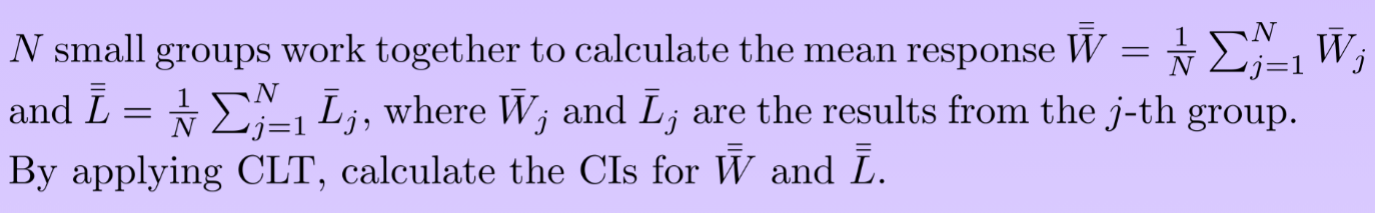

## Sample average - System waiting time

In [7]:
# first n_entities arrivals
arrival_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='arrival']
arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
arrival_df.reset_index(inplace=True, drop=True)
arrival_df.rename(columns={'Clock':'Arrival_Clock'}, inplace=True)

# first n_entities depart
depart_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='depart']
depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
depart_df.reset_index(inplace=True, drop=True)
depart_df.rename(columns={'Clock':'Depart_Clock'}, inplace=True)

W_df = pd.concat([arrival_df[['Replication', 'Event', 'Arrival_Clock']],
                   depart_df[['Event', 'Depart_Clock']]], axis=1)

C:\Users\prade\AppData\Local\Temp\ipykernel_16148\793491776.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_16148\793491776.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])


In [8]:
# W in system/ entity
W_df['W'] =( W_df['Depart_Clock']-W_df['Arrival_Clock']).round(3)
W_df_summ = W_df.groupby(['Replication']).agg({'W': 'mean'}).round(3).reset_index()

In [9]:
print(f'Sample average of system wait time')
lst = W_df_summ['W']
print(f'count: {len(lst)}')
print(f'max: {np.max(lst):.3f} | min: {np.min(lst):.3f}')
print(f'sample mean: {np.mean(lst):.3f} | sample standard dev.: {np.std(lst, ddof=1):.3f}')
z_critical = 1.96  # for 95% CI
margin_error_z = z_critical * (np.std(lst, ddof=1) / np.sqrt(len(lst)))
ci_lower_z = np.mean(lst) - margin_error_z
ci_upper_z = np.mean(lst) + margin_error_z
print(f"95% confidence interval: ({ci_lower_z:.3f}, {ci_upper_z:.3f})")


Sample average of system wait time
count: 100
max: 5.142 | min: 0.334
sample mean: 1.194 | sample standard dev.: 0.719
95% confidence interval: (1.053, 1.335)


## Sample average - System number of entities

In [10]:
# calculate dt
temp = df.groupby(['Replication']).apply(lambda x: x['Clock'].diff(-1)).to_list()
df['dt'] = -np.array(temp)
df['dt*S'] = df['dt']*df['State']

C:\Users\prade\AppData\Local\Temp\ipykernel_16148\1414028157.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp = df.groupby(['Replication']).apply(lambda x: x['Clock'].diff(-1)).to_list()


In [11]:
L_df_summ = df.groupby(['Replication']).agg({'dt*S': 'sum', 'Clock': 'max'})
L_df_summ['L'] = L_df_summ['dt*S']/L_df_summ['Clock']

In [12]:
print(f'Sample average of expected enitities in system')
lst = L_df_summ['L']
print(f'count: {len(lst)}')
print(f'max: {np.max(lst):.3f} | min: {np.min(lst):.3f}')
print(f'sample mean: {np.mean(lst):.3f} | sample standard dev.: {np.std(lst, ddof=1):.3f}')
z_critical = 1.96  # for 95% CI
margin_error_z = z_critical * (np.std(lst, ddof=1) / np.sqrt(len(lst)))
ci_lower_z = np.mean(lst) - margin_error_z
ci_upper_z = np.mean(lst) + margin_error_z
print(f"95% confidence interval: ({ci_lower_z:.3f}, {ci_upper_z:.3f})")


Sample average of expected enitities in system
count: 100
max: 5.949 | min: 0.313
sample mean: 1.374 | sample standard dev.: 0.922
95% confidence interval: (1.193, 1.555)


## Bias in transient state

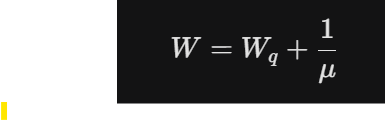

In [13]:
W_df['entity'] = W_df.groupby(['Replication']).cumcount() + 1
W_df['Wq'] = W_df['W'] - 1/service_rate
W_df_mean = W_df.groupby(['entity']).agg({'W': 'mean', 'Wq': 'mean'}).reset_index()

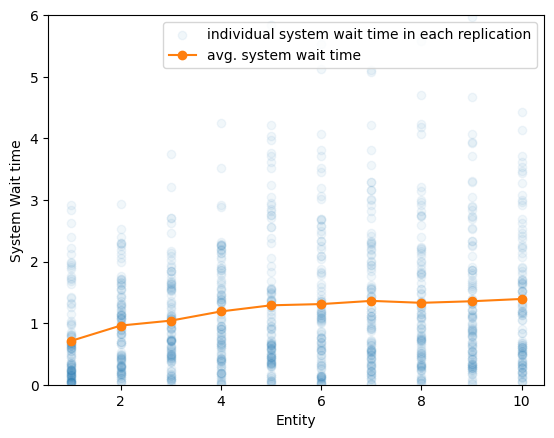

In [14]:
plt.scatter(W_df['entity'], W_df['W'], alpha=0.06, label='individual system wait time in each replication')
plt.plot(W_df_mean['entity'], W_df_mean['W'], label='avg. system wait time', marker='o', color='tab:orange')
plt.xlabel('Entity')
plt.ylabel('System Wait time')
plt.ylim(0, 6)
plt.legend()

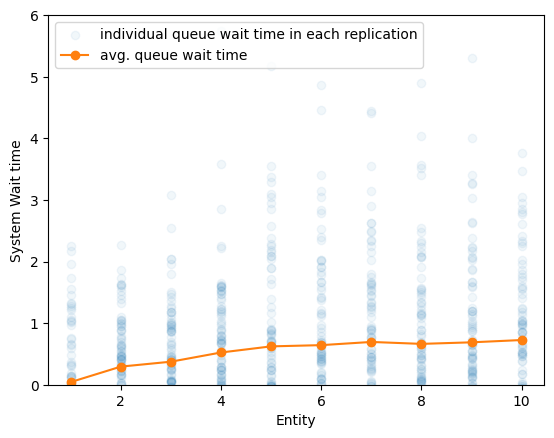

In [15]:
plt.scatter(W_df['entity'], W_df['Wq'], alpha=0.06, label='individual queue wait time in each replication')
plt.plot(W_df_mean['entity'], W_df_mean['Wq'], label='avg. queue wait time', marker='o', color='tab:orange')
plt.xlabel('Entity')
plt.ylabel('System Wait time')
plt.ylim(0, 6)
plt.legend()

# HW2

## Part 1
For the system steady state performance, run simulations, remove the observations
in the warmup, and compare the results with confidence interval when the number
of replications equal to 5, 30, 100. (Hint: the estimation accuracy should improve
as the simulation budget increases)

## running sim for 5, 30, 100 replications

In [16]:
# exponential time
def exp_time_diff(rate):
    return (-np.log(1-np.random.uniform())/rate).item()

In [17]:
np.random.seed(42)
n_entity = 250
tba_fn = exp_time_diff
arrival_rate = 1
service_t_fn = exp_time_diff
service_rate = 1.5
sim5 = MMC_Sim(5, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1) # replication=5
sim30 = MMC_Sim(30, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1) # replication=30
sim100 = MMC_Sim(100, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1) # replication=100
sim5.run_sim()
sim30.run_sim()
sim100.run_sim()


C:\Users\prade\AppData\Local\Temp\ipykernel_16148\2177065499.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.event_table = pd.concat([self.event_table,


In [18]:
df = pd.concat([sim5.event_table, sim30.event_table, sim100.event_table])
df['rep_set'] = float('nan')
mask = df.index == 0
df.loc[mask, 'rep_set'] = [5, 30, 100]
df['rep_set'].ffill(inplace=True)

C:\Users\prade\AppData\Local\Temp\ipykernel_16148\3242284379.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rep_set'].ffill(inplace=True)


## plotting waiting time in system

In [19]:
def plot_wait_time(df):
    # first n_entities arrivals
    arrival_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='arrival']
    arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
    arrival_df.reset_index(inplace=True, drop=True)
    arrival_df.rename(columns={'Clock':'Arrival_Clock'}, inplace=True)

    # first n_entities depart
    depart_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='depart']
    depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
    depart_df.reset_index(inplace=True, drop=True)
    depart_df.rename(columns={'Clock':'Depart_Clock'}, inplace=True)

    W_df = pd.concat([arrival_df[['Replication', 'Event', 'Arrival_Clock']],
                    depart_df[['Event', 'Depart_Clock']]], axis=1)
    # W in system/ entity
    W_df['W'] =( W_df['Depart_Clock']-W_df['Arrival_Clock']).round(3)
    W_df_summ = W_df.groupby(['Replication']).agg({'W': 'mean'}).round(3).reset_index()
    W_df['entity'] = W_df.groupby(['Replication']).cumcount() + 1
    W_df['Wq'] = W_df['W'] - 1/service_rate
    W_df_mean = W_df.groupby(['entity']).agg({'W': 'mean', 'Wq': 'mean'}).reset_index()

    plt.scatter(W_df['entity'], W_df['W'], alpha=0.06, label='individual system wait time in each replication')
    plt.plot(W_df_mean['entity'], W_df_mean['W'], label='avg. system wait time', color='tab:orange')
    plt.xlabel('Entity')
    plt.ylabel('System Wait time')
    plt.ylim(0, 6)
    plt.legend()

C:\Users\prade\AppData\Local\Temp\ipykernel_16148\3035205258.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_16148\3035205258.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])


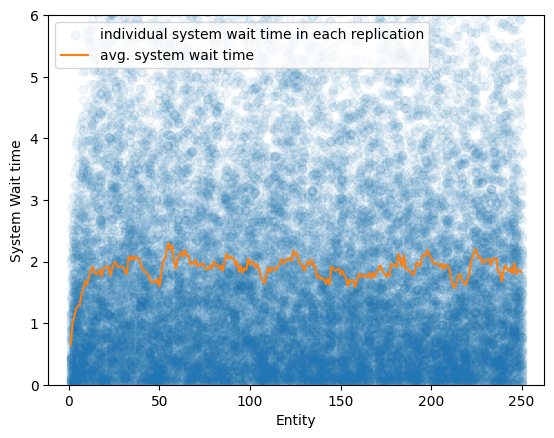

In [20]:
plot_wait_time(df)

 ### considering first 25 entities as transient state; and removing first 25 entities for accuracy metrics

In [21]:
def get_entity_arrivaldepart(df, start):    
    # first n_entities arrivals
    arrival_df = df[['rep_set', 'Replication', 'Event', 'Clock']].loc[df['Event']=='arrival']
    arrival_df = arrival_df.groupby(['rep_set', 'Replication']).apply(lambda x: x.iloc[start:n_entity])
    arrival_df.reset_index(inplace=True, drop=True)
    arrival_df.rename(columns={'Clock':'Arrival_Clock'}, inplace=True)

    # first n_entities depart
    depart_df = df[['rep_set', 'Replication', 'Event', 'Clock']].loc[df['Event']=='depart']
    depart_df = depart_df.groupby(['rep_set', 'Replication']).apply(lambda x: x.iloc[start:n_entity])
    depart_df.reset_index(inplace=True, drop=True)
    depart_df.rename(columns={'Clock':'Depart_Clock'}, inplace=True)

    W_df = pd.concat([arrival_df[['rep_set', 'Replication', 'Event', 'Arrival_Clock']],
                    depart_df[['Event', 'Depart_Clock']]], axis=1)
    # W in system/ entity
    W_df['W'] =( W_df['Depart_Clock']-W_df['Arrival_Clock']).round(3)
    W_df_summ = W_df.groupby(['rep_set', 'Replication']).agg({'W': 'mean'}).round(3).reset_index()
    W_df['entity'] = W_df.groupby(['rep_set', 'Replication']).cumcount() + 1
    W_df['Wq'] = W_df['W'] - 1/service_rate
    W_df_mean = W_df.groupby(['entity']).agg({'W': 'mean', 'Wq': 'mean'}).reset_index()

    return W_df, W_df_mean
    

In [22]:
W_df, W_df_mean = get_entity_arrivaldepart(df, 25)

C:\Users\prade\AppData\Local\Temp\ipykernel_16148\3603356430.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['rep_set', 'Replication']).apply(lambda x: x.iloc[start:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_16148\3603356430.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  depart_df = depart_df.groupby(['rep_set', 'Replication']).apply(lambda x: x.iloc[start:n_enti

### using mean absolute error (MAE)
theoretical W = 2
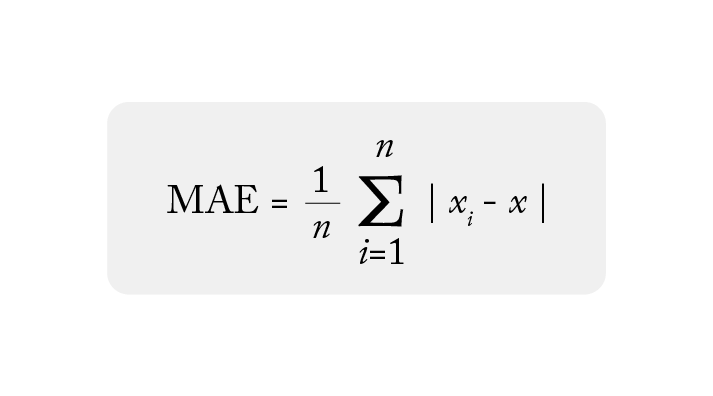

In [23]:
W_df['abs_diff'] = abs(W_df['W']-2)/2
acc = W_df.groupby(['rep_set']).agg({'abs_diff':'mean'})


In [24]:
acc.round(3)

,abs_diff
rep_set,
5.0,0.745
30.0,0.742
100.0,0.705


## Part 2
For the system transit performance, run simulation with 100 replications: 
(1)starting from the empty system; and 
(2) stopping the simulation when 500 pa￾tients finish the service. Plot:

a. the estimated expected times staying in the system,
E[W1], E[W2], . . . ,E[W500].

b. the variation of times staying in the system (standard deviation),
SD[W1], SD[W2], . . . , SD[W500].

In [25]:
replication = 100 # 100 replication
n_entity = 500 # 500 patients
tba_fn = exp_time_diff
arrival_rate = 1
service_t_fn = exp_time_diff
service_rate = 1.5
sim = MMC_Sim(replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1)
sim.run_sim()

C:\Users\prade\AppData\Local\Temp\ipykernel_16148\2177065499.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.event_table = pd.concat([self.event_table,


### plot expected wait time in system

C:\Users\prade\AppData\Local\Temp\ipykernel_16148\3035205258.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_16148\3035205258.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])


Text(0.5, 1.0, 'expected waiting time in system; over 500 entities')

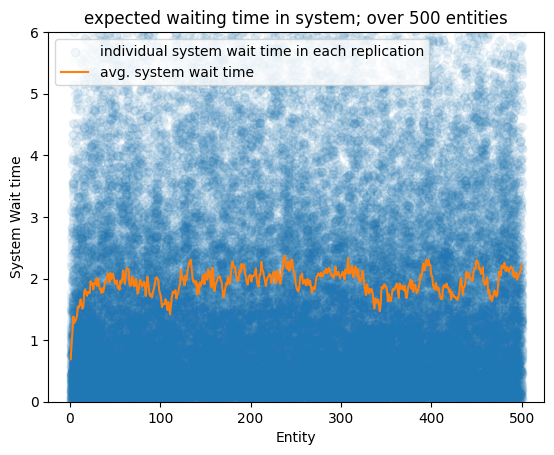

In [26]:
plot_wait_time(sim.event_table)
plt.title('expected waiting time in system; over 500 entities')

### plot standard deviation 

In [27]:
def plot_wait_time_std(df):
    # first n_entities arrivals
    arrival_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='arrival']
    arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
    arrival_df.reset_index(inplace=True, drop=True)
    arrival_df.rename(columns={'Clock':'Arrival_Clock'}, inplace=True)

    # first n_entities depart
    depart_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='depart']
    depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
    depart_df.reset_index(inplace=True, drop=True)
    depart_df.rename(columns={'Clock':'Depart_Clock'}, inplace=True)

    W_df = pd.concat([arrival_df[['Replication', 'Event', 'Arrival_Clock']],
                    depart_df[['Event', 'Depart_Clock']]], axis=1)
    # W in system/ entity
    W_df['W'] =( W_df['Depart_Clock']-W_df['Arrival_Clock']).round(3)
    W_df['entity'] = W_df.groupby(['Replication']).cumcount() + 1
    W_df_mean = W_df.groupby(['entity']).agg({'W': 'std'}).reset_index()

    plt.plot(W_df_mean['entity'], W_df_mean['W'], label='std. system wait time', color='tab:orange')
    plt.plot([1,500], [W_df_mean['W'].mean()]*2, 'k--', label=f'mean of std. = {W_df_mean['W'].mean(): .3f}')
    plt.xlabel('Entity')
    plt.ylabel('std(System Wait time)')
    plt.legend()

C:\Users\prade\AppData\Local\Temp\ipykernel_16148\418597603.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_16148\418597603.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])


Text(0.5, 1.0, 'Standard deviation of system wait time; for 500 entities')

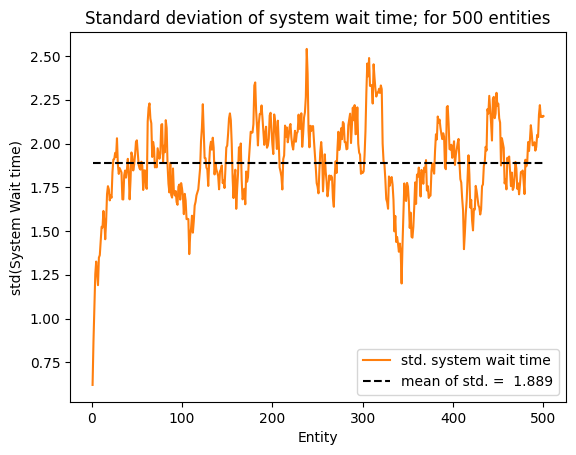

In [28]:
plot_wait_time_std(sim.event_table)
plt.title('Standard deviation of system wait time; for 500 entities')

### Part 3
Repeat part 2 and run simulations under different utilization levels, ρ = 0.3, 0.5, 0.9.
You can fix the arrival rate λ = 1/min and adjust the service rate. Report your
observations. How the times staying in the system change? How the utilization
impact on the warmup length required for steady-state study?

In [29]:
utilization = [0.3, 0.5, 0.9] # utlization 
replication = 100 # 100 replication
n_entity = 500 # 500 patients
tba_fn = exp_time_diff
arrival_rate = 1
service_t_fn = exp_time_diff
sim = MMC_Sim(replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1)
sim.run_sim()

C:\Users\prade\AppData\Local\Temp\ipykernel_16148\2177065499.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.event_table = pd.concat([self.event_table,


C:\Users\prade\AppData\Local\Temp\ipykernel_16148\2177065499.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.event_table = pd.concat([self.event_table,
C:\Users\prade\AppData\Local\Temp\ipykernel_16148\265899044.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_16148\265899044.py:14: FutureWarning: DataFrameGroupBy.ap

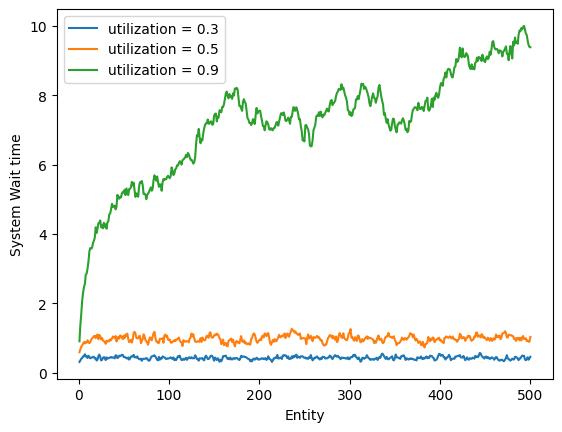

In [30]:
for utility in utilization:
    service_rate = arrival_rate/utility
    sim = MMC_Sim(replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1)
    sim.run_sim()
    df = sim.event_table
    # first n_entities arrivals
    arrival_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='arrival']
    arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
    arrival_df.reset_index(inplace=True, drop=True)
    arrival_df.rename(columns={'Clock':'Arrival_Clock'}, inplace=True)

    # first n_entities depart
    depart_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='depart']
    depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
    depart_df.reset_index(inplace=True, drop=True)
    depart_df.rename(columns={'Clock':'Depart_Clock'}, inplace=True)

    W_df = pd.concat([arrival_df[['Replication', 'Event', 'Arrival_Clock']],
                    depart_df[['Event', 'Depart_Clock']]], axis=1)
    # W in system/ entity
    W_df['W'] =( W_df['Depart_Clock']-W_df['Arrival_Clock']).round(3)
    W_df_summ = W_df.groupby(['Replication']).agg({'W': 'mean'}).round(3).reset_index()
    W_df['entity'] = W_df.groupby(['Replication']).cumcount() + 1
    W_df['Wq'] = W_df['W'] - 1/service_rate
    W_df_mean = W_df.groupby(['entity']).agg({'W': 'mean', 'Wq': 'mean'}).reset_index()

    
    plt.plot(W_df_mean['entity'], W_df_mean['W'], label=f'utilization = {utility}')

plt.xlabel('Entity')
plt.ylabel('System Wait time')
# plt.ylim(0, 6)
plt.legend()
    

### if utilization is increasing; service rate is decreasing, as a result the waiting time increases

## HW3 Question2

Problem 2 (20 points) Run the steady-state simulation of M/M/1 queue in HW2 problem 3.1 with
the utilization ρ = 0.3, 0.5, 0.9. Record the detailed sample paths of entity waiting
times {Yi} in the queues with the run length equal to 100 after warm-up and set the
number of replications equal to 100. Fit the AR(1) Surrogate Model on the time series
of waiting time,
Yi = µ + ϕ · (Yi−1 − µ) + ei (2)
for i = 1, 2, . . . with e1, e2, . . . following the Normal distribution N(0, σ2
) and |ϕ| < 1.
1. Estimate the AR(1) model coefficients µ, ϕ, σ2 under different utilization levels
ρ = 0.3, 0.5, 0.9. Report what are your observations?
2. Conduct one-step forward prediction and record the statistics of prediction error.

In [102]:
# linear regresion; AR(1)
def ar1(df):
    X = df['lag_1'].to_list()
    y = df['W'].to_list()

    X = sm.add_constant(X) # Add intercept
    model = sm.OLS(y, X).fit()

    print(model.summary())

    residuals = model.resid

    return model, residuals

In [103]:
# plot residuals
def plot_residuals(residuals):
    std = np.std(residuals).item()
    mean = np.mean(residuals).item()
    plt.hist(residuals, bins=15, label=f'sd: {std:.3f} | var: {std**2: .3f}')
    plt.title(f'Residuals normally distributed: N({mean:.2f},{std**2: .2f})')
    plt.legend()

In [121]:
# forecast
def forecast(model, data, window=20):
    x = data
    last = x[-window]
    intercept = model.params[0]
    slope = model.params[1]
    prediction=[]
    for _ in range(window-1):
        prediction.append(intercept+slope*last)
        last = prediction[-1]
    prediction_index = np.arange(len(x)-window+1,len(x),1)

    # mena absolute error
    error = np.array(x[-window+1:])-np.array(prediction)
    mae = np.mean(np.abs(error)).item()
    sd_error = np.std(error).item()

    plt.plot(W_df_mean['entity'], W_df_mean['W'], label='actual')
    plt.plot(prediction_index, prediction, label='forecast')
    plt.title(f'Mean Absolute error: {mae:.3f}  |   sd.error:{sd_error:.3f} |   forecast window:{window}')
    plt.legend()

In [105]:
utilization = [0.3, 0.5, 0.9] # utlization 
replication = 100 # 100 replication
n_entity = 100 # 100 patients
tba_fn = exp_time_diff
arrival_rate = 1
service_t_fn = exp_time_diff

### for utility rate = 0.3

C:\Users\prade\AppData\Local\Temp\ipykernel_16756\2177065499.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.event_table = pd.concat([self.event_table,
C:\Users\prade\AppData\Local\Temp\ipykernel_16756\376657431.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_16756\376657431.py:18: FutureWarning: DataFrameGroupBy.a

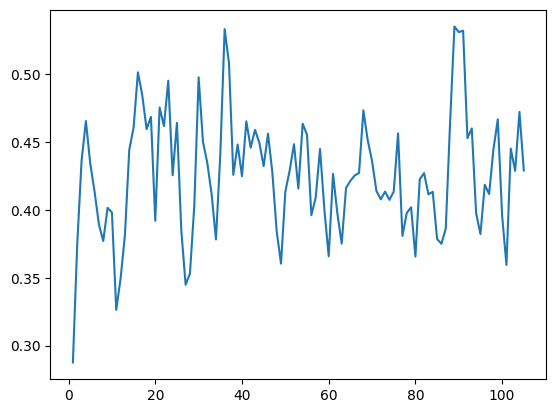

In [120]:
utility = 0.3
n_entity = 105 # Since stable state begins by entity 2
# setting service for different utility rate; keeping arrival rate constant
service_rate = arrival_rate/utility 

sim = MMC_Sim(replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1)
sim.run_sim()
df = sim.event_table

# first n_entities arrivals
arrival_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='arrival']
arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
arrival_df.reset_index(inplace=True, drop=True)
arrival_df.rename(columns={'Clock':'Arrival_Clock'}, inplace=True)

# first n_entities depart
depart_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='depart']
depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
depart_df.reset_index(inplace=True, drop=True)
depart_df.rename(columns={'Clock':'Depart_Clock'}, inplace=True)

W_df = pd.concat([arrival_df[['Replication', 'Event', 'Arrival_Clock']],
                depart_df[['Event', 'Depart_Clock']]], axis=1)

# W in system/ entity
W_df['W'] =( W_df['Depart_Clock']-W_df['Arrival_Clock']).round(3)
W_df_summ = W_df.groupby(['Replication']).agg({'W': 'mean'}).round(3).reset_index()
W_df['entity'] = W_df.groupby(['Replication']).cumcount() + 1
W_df['Wq'] = W_df['W'] - 1/service_rate
W_df_mean = W_df.groupby(['entity']).agg({'W': 'mean', 'Wq': 'mean'}).reset_index()



plt.plot(W_df_mean['entity'], W_df_mean['W'], label=f'utilization = {utility}')


In [ ]:
# create lag 1 variable
regression_03 = W_df[['Replication','W']]
regression_03['lag_1'] = regression_03.groupby(['Replication']).shift(1)
regression_03.dropna(inplace=True)

# get last 100 entities after transient state
regression_03 = regression_03.groupby('Replication').tail(100)

In [108]:
model_03, residual_03 = ar1(regression_03)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.270
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     3698.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:12:57   Log-Likelihood:                -4341.7
No. Observations:               10000   AIC:                             8687.
Df Residuals:                    9998   BIC:                             8702.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2105      0.005     39.773      0.0

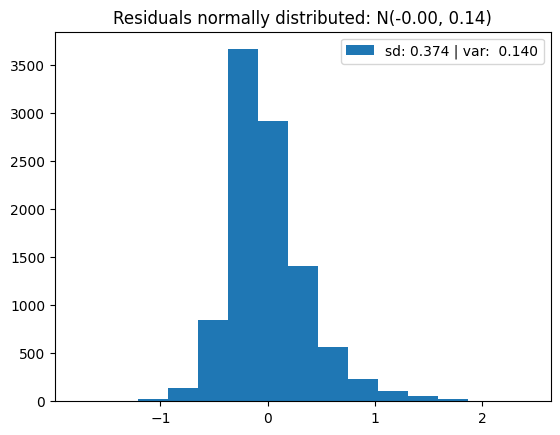

In [109]:
plot_residuals(residual_03)

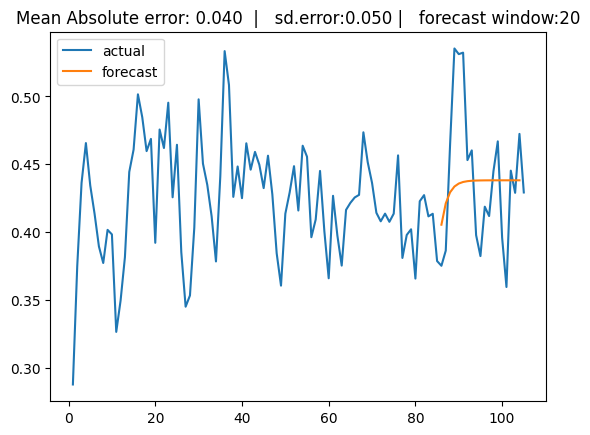

In [122]:
forecast(model_03, W_df_mean['W'].to_list())

### for utility rate = 0.5

C:\Users\prade\AppData\Local\Temp\ipykernel_16756\2177065499.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.event_table = pd.concat([self.event_table,
C:\Users\prade\AppData\Local\Temp\ipykernel_16756\1581425134.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_16756\1581425134.py:18: FutureWarning: DataFrameGroupBy

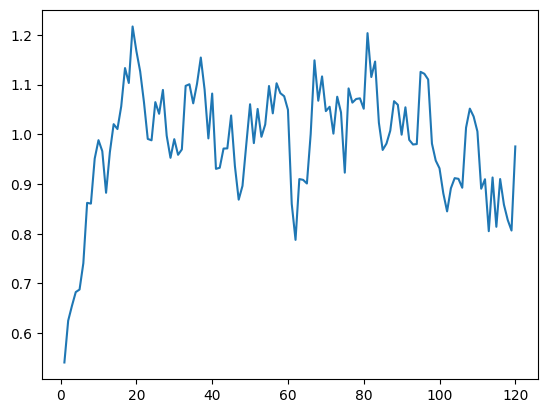

In [130]:
utility = 0.5
n_entity = 120 # Since stable state begins by entity 2
# setting service for different utility rate; keeping arrival rate constant
service_rate = arrival_rate/utility 

sim = MMC_Sim(replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1)
sim.run_sim()
df = sim.event_table

# first n_entities arrivals
arrival_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='arrival']
arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
arrival_df.reset_index(inplace=True, drop=True)
arrival_df.rename(columns={'Clock':'Arrival_Clock'}, inplace=True)

# first n_entities depart
depart_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='depart']
depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
depart_df.reset_index(inplace=True, drop=True)
depart_df.rename(columns={'Clock':'Depart_Clock'}, inplace=True)

W_df = pd.concat([arrival_df[['Replication', 'Event', 'Arrival_Clock']],
                depart_df[['Event', 'Depart_Clock']]], axis=1)

# W in system/ entity
W_df['W'] =( W_df['Depart_Clock']-W_df['Arrival_Clock']).round(3)
W_df_summ = W_df.groupby(['Replication']).agg({'W': 'mean'}).round(3).reset_index()
W_df['entity'] = W_df.groupby(['Replication']).cumcount() + 1
W_df['Wq'] = W_df['W'] - 1/service_rate
W_df_mean = W_df.groupby(['entity']).agg({'W': 'mean', 'Wq': 'mean'}).reset_index()



plt.plot(W_df_mean['entity'], W_df_mean['W'], label=f'utilization = {utility}')


In [ ]:
# create lag 1 variable
regression_05 = W_df[['Replication','W']]
regression_05['lag_1'] = regression_05.groupby(['Replication']).shift(1)
regression_05.dropna(inplace=True)

# get last 100 entities after transient state
regression_05 = regression_05.groupby('Replication').tail(100)

In [132]:
model_05, residual_05 = ar1(regression_05)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                 1.331e+04
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:16:30   Log-Likelihood:                -9847.6
No. Observations:               10000   AIC:                         1.970e+04
Df Residuals:                    9998   BIC:                         1.971e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2441      0.009     26.472      0.0

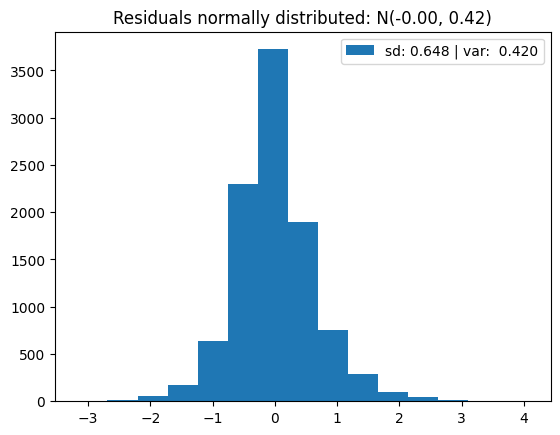

In [133]:
plot_residuals(residual_05)

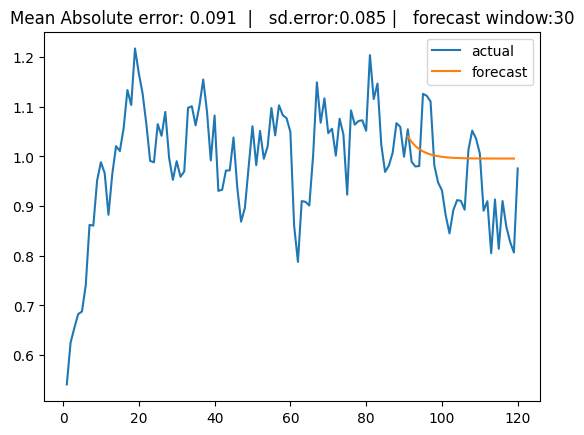

In [134]:
forecast(model_05, W_df_mean['W'].to_list(), window=30)

### for utility rate = 0.9

C:\Users\prade\AppData\Local\Temp\ipykernel_16756\2177065499.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.event_table = pd.concat([self.event_table,
C:\Users\prade\AppData\Local\Temp\ipykernel_16756\3173625854.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_16756\3173625854.py:18: FutureWarning: DataFrameGroupBy

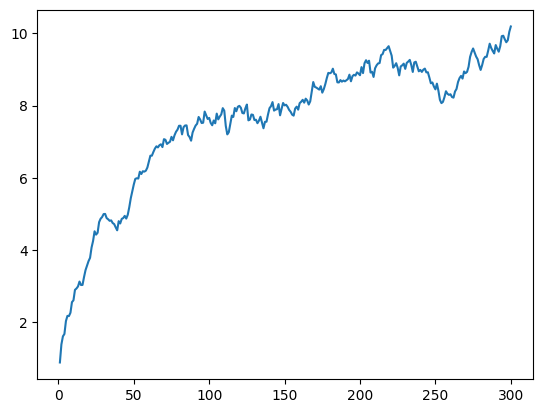

In [126]:
utility = 0.9
n_entity = 300 # Since stable state begins by entity 2
# setting service for different utility rate; keeping arrival rate constant
service_rate = arrival_rate/utility 

sim = MMC_Sim(replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1)
sim.run_sim()
df = sim.event_table

# first n_entities arrivals
arrival_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='arrival']
arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
arrival_df.reset_index(inplace=True, drop=True)
arrival_df.rename(columns={'Clock':'Arrival_Clock'}, inplace=True)

# first n_entities depart
depart_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='depart']
depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
depart_df.reset_index(inplace=True, drop=True)
depart_df.rename(columns={'Clock':'Depart_Clock'}, inplace=True)

W_df = pd.concat([arrival_df[['Replication', 'Event', 'Arrival_Clock']],
                depart_df[['Event', 'Depart_Clock']]], axis=1)

# W in system/ entity
W_df['W'] =( W_df['Depart_Clock']-W_df['Arrival_Clock']).round(3)
W_df_summ = W_df.groupby(['Replication']).agg({'W': 'mean'}).round(3).reset_index()
W_df['entity'] = W_df.groupby(['Replication']).cumcount() + 1
W_df['Wq'] = W_df['W'] - 1/service_rate
W_df_mean = W_df.groupby(['entity']).agg({'W': 'mean', 'Wq': 'mean'}).reset_index()



plt.plot(W_df_mean['entity'], W_df_mean['W'], label=f'utilization = {utility}')


In [ ]:
# create lag 1 variable
regression_09 = W_df[['Replication','W']]
regression_09['lag_1'] = regression_09.groupby(['Replication']).shift(1)
regression_09.dropna(inplace=True)

# get last 100 entities after transient state
regression_09 = regression_09.groupby('Replication').tail(100)

In [128]:
model_09, residual_09 = ar1(regression_09)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                 4.517e+05
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:15:58   Log-Likelihood:                -16436.
No. Observations:               10000   AIC:                         3.288e+04
Df Residuals:                    9998   BIC:                         3.289e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1076      0.018      5.874      0.0

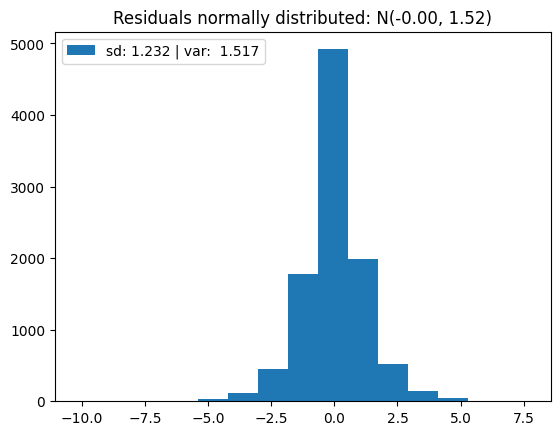

In [119]:
plot_residuals(residual_09)

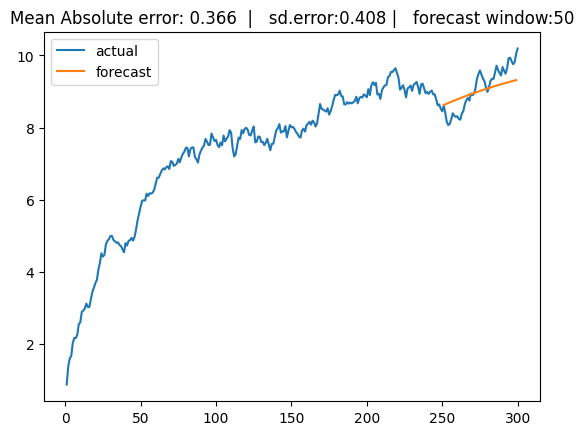

In [129]:
forecast(model_09, W_df_mean['W'].to_list(), window=50)